In [28]:
import pandas as pd
import numpy as np
import pickle

prediction_path = "/home/davide_raffaelli/london/LOBFrame/loggers/results/100_lags_fm_2chan/prediction.pkl"

all_prices, sanity_check_labels, all_targets, all_predictions, all_probs = (
    pd.read_pickle(prediction_path)
)

In [53]:
def is_shifted(a, b):
    # Must be same length
    if len(a) != len(b):
        return False, None

    n = len(a)
    for shift in range(-n + 1, n):  # check all possible shifts
        match = True
        for i in range(n):
            j = i + shift
            if 0 <= j < n and a[i] != b[j]:
                match = False
                break
        if match:
            return True, shift
    return False, None


is_shifted(sanity_check_labels[0:1000], all_targets[0:1000])

(True, -148)

In [48]:
len(sanity_check_labels[250 : 7397621 + 250])

7397621

In [55]:
sum(sanity_check_labels[148 : 7396391 + 148] == all_targets[:7396391])

np.int64(5274283)

In [59]:
np.array(sanity_check_labels[148:200])

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 0, 0])

In [60]:
all_targets[:52]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 1, 1, 1, 1, 0, 0])

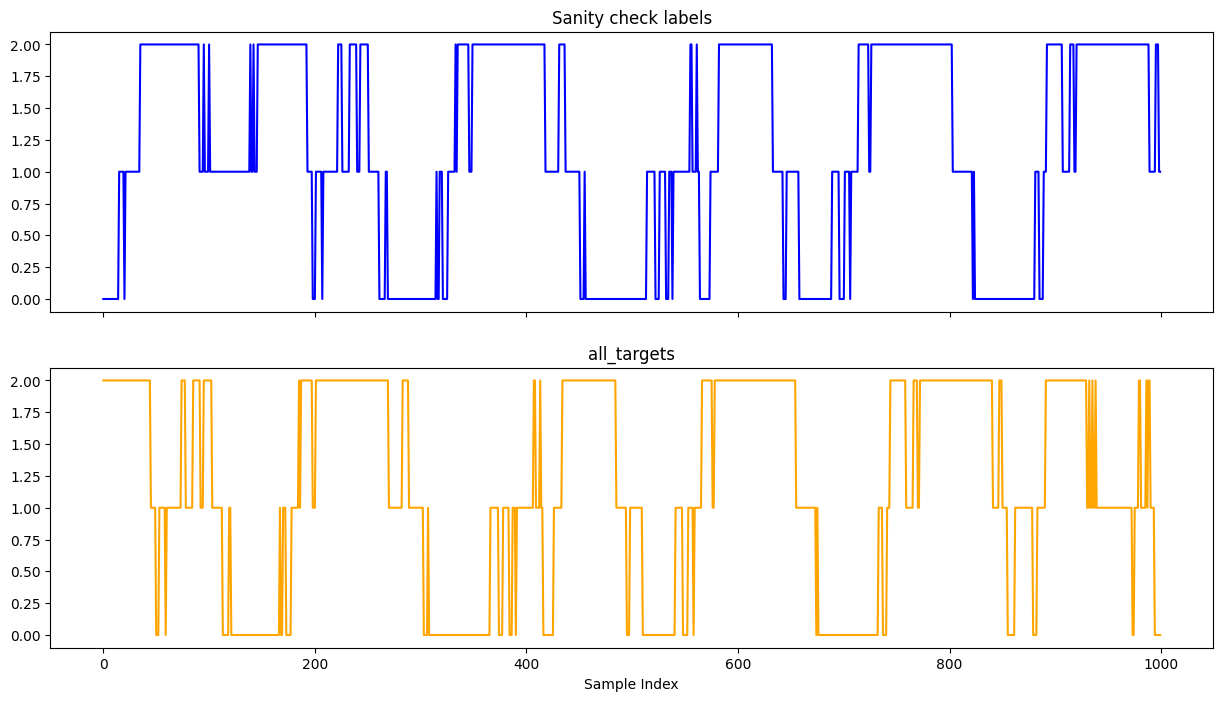

In [52]:
# plot to visually inspect in two plots one above the other
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
axs[0].plot(
    sanity_check_labels[0:1000],
    label="Sanity check labels",
    color="blue",
)
axs[0].set_title("Sanity check labels")
axs[1].plot(all_targets[0:1000], label="Predictions", color="orange")
axs[1].set_title("all_targets")
plt.xlabel("Sample Index")
plt.show()

In [30]:
# compute f1 score
from sklearn.metrics import f1_score
from sklearn.metrics import matthews_corrcoef

f1 = f1_score(all_targets, all_predictions, average="macro")
mcc = matthews_corrcoef(all_targets, all_predictions)

print(f"f1: {f1}, mcc: {mcc}")

f1: 0.5087861056878704, mcc: 0.29859516015557336
